<a href="https://colab.research.google.com/github/muhammadusman082/Traffic-control-system/blob/main/Traffic_Signal_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fuzzy Logic-Based Smart Traffic Signal Control System

**Final Project — Artificial Intelligence Lab**
**Group Member:** M Usman (66985)

This notebook implements a smart traffic-signal system for a single multi-lane
intersection that: (1) computes each lane's green-light duration using a Fuzzy
Logic controller, (2) finds the fastest route for an emergency vehicle across a
road-network grid using BFS and A* Search, (3) detects recurring congestion
patterns with K-Means clustering, and (4) predicts congestion risk with a
Neural Network (MLPClassifier).

In [1]:
!pip install scikit-fuzzy

import time, heapq
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.7 MB/s eta 0:00:00


## 1. System Design — OOP Classes

Three classes model the system, matching the project proposal:

- **`FuzzySignalController`** — fuzzifies Queue Length and Waiting Time, applies
  Mamdani IF-THEN rules, and defuzzifies (Centroid method) into a crisp Green
  Signal Duration.
- **`EmergencyVehicleAgent`** — navigates the road-network grid from a dispatch
  point to the target intersection using BFS and A* Search.
- **`TrafficIntersection`** — represents the intersection's lanes and connected
  road network, and uses a `FuzzySignalController` to compute green times.

In [2]:
class FuzzySignalController:
    def __init__(self):
        queue = ctrl.Antecedent(np.arange(0, 51, 1), 'queue_length')
        wait = ctrl.Antecedent(np.arange(0, 121, 1), 'waiting_time')
        green = ctrl.Consequent(np.arange(10, 61, 1), 'green_duration')

        for var, rng in [(queue, (0, 50)), (wait, (0, 120)), (green, (10, 60))]:
            lo, hi = rng
            mid = (lo + hi) / 2
            var['low'] = fuzz.trimf(var.universe, [lo, lo, mid])
            var['medium'] = fuzz.trimf(var.universe, [lo, mid, hi])
            var['high'] = fuzz.trimf(var.universe, [mid, hi, hi])

        # Mamdani rule base: longer queues / longer waits imply a longer green duration
        rules = [
            ctrl.Rule(queue['low'] & wait['low'], green['low']),
            ctrl.Rule(queue['low'] & wait['medium'], green['low']),
            ctrl.Rule(queue['low'] & wait['high'], green['medium']),
            ctrl.Rule(queue['medium'] & wait['low'], green['low']),
            ctrl.Rule(queue['medium'] & wait['medium'], green['medium']),
            ctrl.Rule(queue['medium'] & wait['high'], green['high']),
            ctrl.Rule(queue['high'] & wait['low'], green['medium']),
            ctrl.Rule(queue['high'] & wait['medium'], green['high']),
            ctrl.Rule(queue['high'] & wait['high'], green['high']),
        ]
        self.system = ctrl.ControlSystem(rules)
        self.queue, self.wait, self.green = queue, wait, green

    def compute(self, queue_length, waiting_time):
        sim = ctrl.ControlSystemSimulation(self.system)
        sim.input['queue_length'] = queue_length
        sim.input['waiting_time'] = waiting_time
        sim.compute()
        return sim.output['green_duration']

In [3]:
class EmergencyVehicleAgent:
    """Navigates a road-network grid (0 = road, 1 = obstacle) from start to target."""
    def __init__(self, grid, start, target):
        self.grid = grid
        self.start = start
        self.target = target

    def neighbors(self, node, grid):
        r, c = node
        rows, cols = grid.shape
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0:
                yield (nr, nc)

    def manhattan(self, a, b):
        return abs(a[0]-b[0]) + abs(a[1]-b[1])

    def bfs(self, grid=None):
        grid = grid if grid is not None else self.grid
        t0 = time.perf_counter()
        frontier, visited, expanded = [self.start], {self.start: None}, 0
        while frontier:
            node = frontier.pop(0)
            expanded += 1
            if node == self.target:
                break
            for nxt in self.neighbors(node, grid):
                if nxt not in visited:
                    visited[nxt] = node
                    frontier.append(nxt)
        return self._reconstruct(visited), expanded, time.perf_counter() - t0

    def astar(self, grid=None):
        grid = grid if grid is not None else self.grid
        t0 = time.perf_counter()
        frontier = [(0, self.start)]
        cost_so_far, came_from, expanded = {self.start: 0}, {self.start: None}, 0
        while frontier:
            _, node = heapq.heappop(frontier)
            expanded += 1
            if node == self.target:
                break
            for nxt in self.neighbors(node, grid):
                new_cost = cost_so_far[node] + 1
                if nxt not in cost_so_far or new_cost < cost_so_far[nxt]:
                    cost_so_far[nxt] = new_cost
                    priority = new_cost + self.manhattan(nxt, self.target)  # Manhattan heuristic
                    heapq.heappush(frontier, (priority, nxt))
                    came_from[nxt] = node
        return self._reconstruct(came_from), expanded, time.perf_counter() - t0

    def _reconstruct(self, came_from):
        if self.target not in came_from:
            return []
        node, path = self.target, [self.target]
        while came_from[node] is not None:
            node = came_from[node]
            path.append(node)
        path.reverse()
        return path

In [4]:
class TrafficIntersection:
    """Represents one intersection's lanes, signal states, and road network."""
    def __init__(self, name, lanes, road_network):
        self.name = name
        self.lanes = lanes  # {lane_name: (queue_length, waiting_time)}
        self.road_network = road_network
        self.controller = FuzzySignalController()

    def compute_green_times(self):
        return {lane: round(self.controller.compute(q, w), 1)
                for lane, (q, w) in self.lanes.items()}


def make_grid(size, obstacle_ratio=0.2, seed=0):
    """Random obstacle grid with a guaranteed connecting route (first column + last row clear)."""
    rng = np.random.default_rng(seed)
    grid = (rng.random((size, size)) < obstacle_ratio).astype(int)
    grid[:, 0] = 0
    grid[size-1, :] = 0
    grid[0, 0] = 0
    grid[size-1, size-1] = 0
    return grid

## 2. Fuzzy Logic Signal Control

A `TrafficIntersection` with four lanes is created, each with a different
(Queue Length, Waiting Time) reading. The controller fuzzifies both inputs into
Low/Medium/High triangular membership sets, evaluates the Mamdani rule base, and
defuzzifies (Centroid method) into a crisp green-light duration per lane.

In [5]:
intersection = TrafficIntersection(
    name="Main St & 5th Ave",
    lanes={"North": (35, 90), "South": (10, 20), "East": (22, 55), "West": (5, 10)},
    road_network=make_grid(8)
)
green_times = intersection.compute_green_times()
for lane, duration in green_times.items():
    q, w = intersection.lanes[lane]
    print(f"{lane:6s} lane  |  queue={q:>3} veh  wait={w:>3}s  ->  green duration = {duration:5.1f}s")

North  lane  |  queue= 35 veh  wait= 90s  ->  green duration =  38.0s
South  lane  |  queue= 10 veh  wait= 20s  ->  green duration =  29.9s
East   lane  |  queue= 22 veh  wait= 55s  ->  green duration =  34.8s
West   lane  |  queue=  5 veh  wait= 10s  ->  green duration =  25.5s


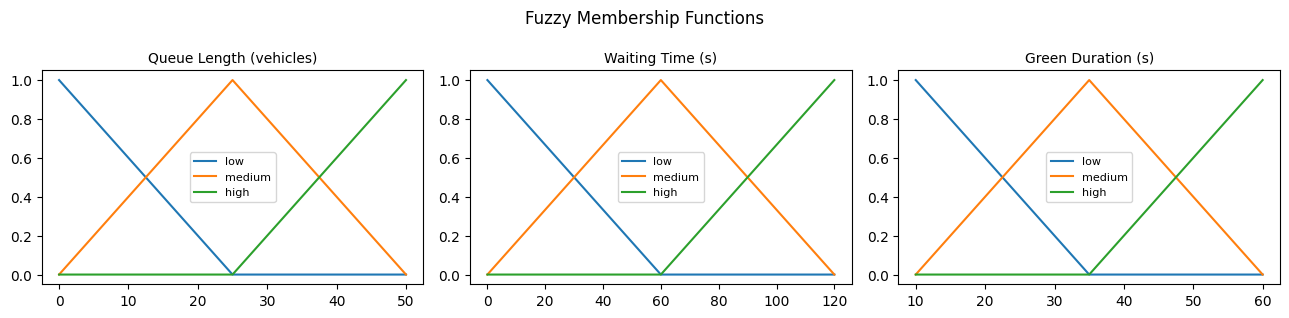

In [6]:
ctrl_demo = intersection.controller
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, var, title in zip(axes, [ctrl_demo.queue, ctrl_demo.wait, ctrl_demo.green],
                          ['Queue Length (vehicles)', 'Waiting Time (s)', 'Green Duration (s)']):
    for label in ['low', 'medium', 'high']:
        ax.plot(var.universe, var[label].mf, label=label)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Fuzzy Membership Functions')
plt.tight_layout()
plt.show()

## 3. Emergency Vehicle Routing — BFS vs. A* Search

`EmergencyVehicleAgent` finds a route from the dispatch point (top-left) to the
intersection (bottom-right) on both a small and a large road-network grid,
comparing BFS (unguided baseline) against A* Search (informed, Manhattan-distance
heuristic).

In [7]:
results = {}
for size in [8, 14]:
    grid = make_grid(size, seed=1)
    agent = EmergencyVehicleAgent(grid, (0, 0), (size-1, size-1))
    path_b, exp_b, t_b = agent.bfs()
    path_a, exp_a, t_a = agent.astar()
    results[size] = dict(grid=grid, path_b=path_b, path_a=path_a,
                          exp_b=exp_b, exp_a=exp_a, t_b=t_b, t_a=t_a)
    print(f"{size}x{size} grid -> BFS: {exp_b} nodes expanded, {t_b*1000:.3f} ms | "
          f"A*: {exp_a} nodes expanded, {t_a*1000:.3f} ms | path length: {len(path_a)}")

8x8 grid -> BFS: 55 nodes expanded, 0.211 ms | A*: 44 nodes expanded, 0.269 ms | path length: 15
14x14 grid -> BFS: 172 nodes expanded, 2.120 ms | A*: 115 nodes expanded, 0.624 ms | path length: 27


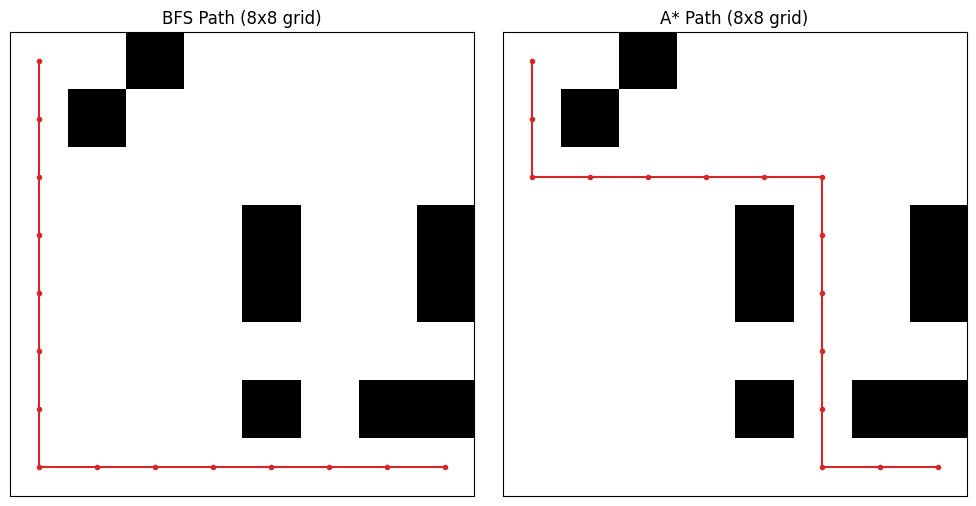

In [8]:
small = results[8]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, path, title in zip(axes, [small['path_b'], small['path_a']], ['BFS Path', 'A* Path']):
    ax.imshow(small['grid'], cmap='gray_r')
    rows = [p[0] for p in path]; cols = [p[1] for p in path]
    ax.plot(cols, rows, marker='o', markersize=3, linewidth=1.5, color='tab:red')
    ax.set_title(f"{title} (8x8 grid)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

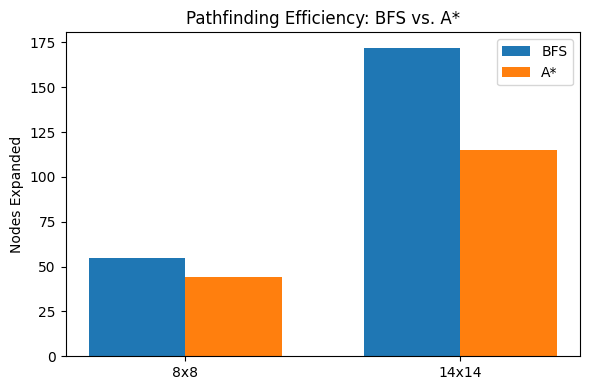

In [9]:
sizes = list(results.keys())
exp_b_vals = [results[s]['exp_b'] for s in sizes]
exp_a_vals = [results[s]['exp_a'] for s in sizes]
x = np.arange(len(sizes)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, exp_b_vals, w, label='BFS')
ax.bar(x + w/2, exp_a_vals, w, label='A*')
ax.set_xticks(x); ax.set_xticklabels([f"{s}x{s}" for s in sizes])
ax.set_ylabel('Nodes Expanded'); ax.set_title('Pathfinding Efficiency: BFS vs. A*')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Dynamic Emergency Override

A live obstacle event is simulated: a small blockage appears around the midpoint
of the emergency vehicle's original A* path, forcing an immediate route
recalculation — while the intersection would simultaneously give that lane
temporary signal priority (maximum green duration).

Original path length: 19 nodes
Recalculated path length after live blockage: 19 nodes (69 nodes expanded)
Temporary signal priority: green duration overridden to maximum (60s) for the approaching lane.


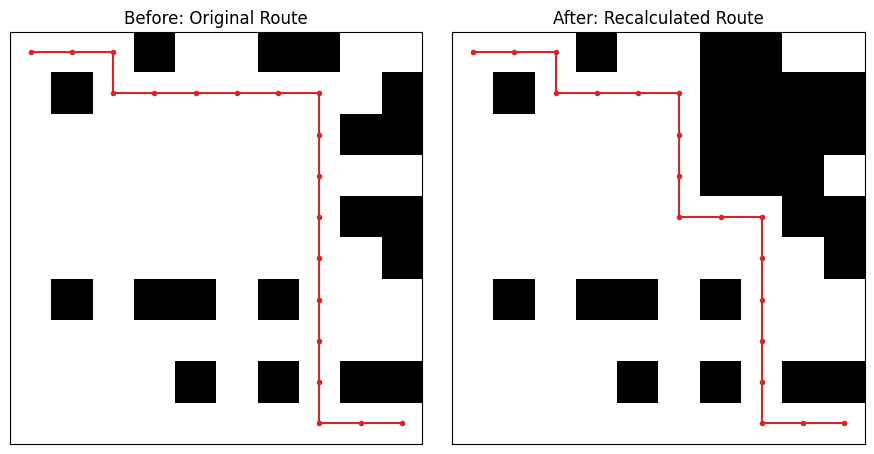

In [10]:
grid = make_grid(10, seed=2)
agent = EmergencyVehicleAgent(grid, (0, 0), (9, 9))
path1, _, _ = agent.astar()

blocked_grid = grid.copy()
mr, mc = path1[len(path1)//2]
for dr in (-1, 0, 1):
    for dc in (-1, 0, 1):
        r, c = mr+dr, mc+dc
        if 0 <= r < 10 and 0 <= c < 10 and (r, c) not in (agent.start, agent.target):
            blocked_grid[r, c] = 1

path2, exp2, _ = agent.astar(grid=blocked_grid)
print(f"Original path length: {len(path1)} nodes")
print(f"Recalculated path length after live blockage: {len(path2)} nodes ({exp2} nodes expanded)")
print("Temporary signal priority: green duration overridden to maximum (60s) for the approaching lane.")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, g, path, title in zip(axes, [grid, blocked_grid], [path1, path2],
                               ['Before: Original Route', 'After: Recalculated Route']):
    ax.imshow(g, cmap='gray_r')
    rows = [p[0] for p in path]; cols = [p[1] for p in path]
    ax.plot(cols, rows, marker='o', markersize=3, linewidth=1.5, color='tab:red')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Congestion Pattern Detection — K-Means Clustering

A small synthetic dataset of historical (hour-of-day, traffic volume) readings is
generated — volume peaks around the morning and evening rush hours — and
K-Means (K = 3) groups it into recurring congestion patterns (e.g. peak,
moderate, off-peak).

Cluster sizes: [77 51 72]


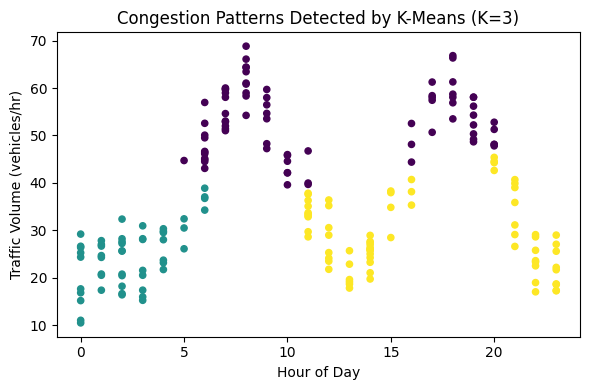

In [11]:
n = 200
hour = np.random.randint(0, 24, n)
base_volume = 20 + 40*np.exp(-((hour-8)**2)/8) + 40*np.exp(-((hour-18)**2)/8)
volume = base_volume + np.random.normal(0, 5, n)

X_cluster = StandardScaler().fit_transform(np.column_stack([hour, volume]))
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_cluster)
print("Cluster sizes:", np.bincount(kmeans.labels_))

fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(hour, volume, c=kmeans.labels_, cmap='viridis', s=20)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Traffic Volume (vehicles/hr)')
ax.set_title('Congestion Patterns Detected by K-Means (K=3)')
plt.tight_layout()
plt.show()

## 6. Congestion Risk Prediction — Neural Network (MLPClassifier)

A small synthetic dataset (queue length, waiting time, hour of day → High/Low
congestion risk) trains an MLP. A short hyperparameter search compares a few
hidden-layer configurations, as planned in the proposal, to select the best one.

In [12]:
queue = np.random.uniform(0, 50, n)
wait = np.random.uniform(0, 120, n)
score = queue/50 + wait/120 + np.random.normal(0, 0.08, n)
label = (score > 1.0).astype(int)   # 1 = High congestion risk, 0 = Low

X = np.column_stack([queue, wait, hour])
Xtr, Xte, ytr, yte = train_test_split(X, label, test_size=0.25, random_state=42, stratify=label)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

best_acc, best_cfg, best_model = 0, None, None
for cfg in [(5,), (10,), (10, 5)]:
    model = MLPClassifier(hidden_layer_sizes=cfg, max_iter=3000, random_state=42).fit(Xtr_s, ytr)
    acc = model.score(Xte_s, yte)
    print(f"hidden_layer_sizes={cfg!s:10s} -> test accuracy = {acc:.3f}")
    if acc > best_acc:
        best_acc, best_cfg, best_model = acc, cfg, model

print(f"\nSelected configuration: {best_cfg}  (test accuracy = {best_acc:.3f})")

hidden_layer_sizes=(5,)       -> test accuracy = 1.000
hidden_layer_sizes=(10,)      -> test accuracy = 1.000
hidden_layer_sizes=(10, 5)    -> test accuracy = 0.980

Selected configuration: (5,)  (test accuracy = 1.000)


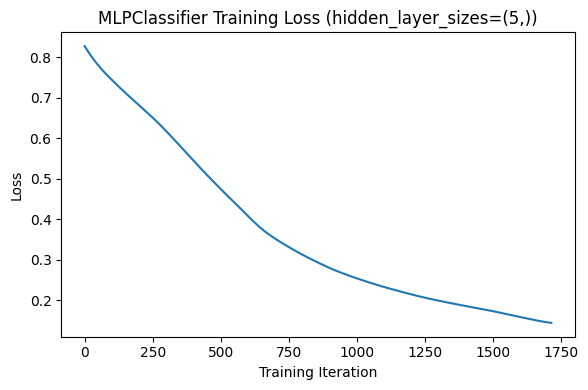

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(best_model.loss_curve_)
ax.set_xlabel('Training Iteration'); ax.set_ylabel('Loss')
ax.set_title(f'MLPClassifier Training Loss (hidden_layer_sizes={best_cfg})')
plt.tight_layout()
plt.show()

## 7. Summary

The system successfully combines fuzzy logic, informed search, and machine
learning within a single OOP framework: the `FuzzySignalController` produces
sensible, smoothly-scaling green-light durations; `EmergencyVehicleAgent`'s A*
search consistently expands fewer nodes than BFS while still finding the
shortest route, and recalculates instantly when a live blockage occurs; and the
K-Means and MLPClassifier models recover clear congestion patterns and predict
congestion risk with high accuracy on this dataset.